# Electrostatic Capacitance Extraction with Palace

We use `gsim.palace.ElectrostaticSim` to extract the **plate-to-plate (mutual)
capacitance** of the IHP `cmim` (MIM capacitor) cell and compare it against the IHP
PDK compact model. The bottom plate is on Metal5
(terminal `T1` = SPICE `MINUS`), the top plate on TopMetal1 (`T2` = `PLUS`), joined
by a 10x10 array of Vmim vias through a 0.19 um SiO2 MIM dielectric.

Palace writes two matrices: `terminal-C.csv` (Maxwell — self-cap on the diagonal,
negative induced charge off-diagonal) and `terminal-Cm.csv` (mutual/"SPICE" — its
off-diagonal `Cm[i,j] = -C[i,j]` is the physical two-terminal capacitor). The MIM cap
value is `Cm[1,2]`, which is exactly what the PDK `cap_cmim` model describes.

The IHP `cap_cmim` is a 2-terminal model with an area + perimeter law (plate-to-plate
only; substrate parasitics are left to extraction). See
[`capacitors_mod.lib`](https://github.com/IHP-GmbH/IHP-Open-PDK/blob/main/ihp-sg13g2/libs.tech/ngspice/models/capacitors_mod.lib).

**Limitation:** one terminal per layer — multiple electrodes on the same layer (e.g.
interdigitated caps) are not yet supported.

**Requirements:** IHP PDK (`uv pip install ihp-gdsfactory`) and a
[GDSFactory+](https://gdsfactory.com) account for cloud simulation.

### Load IHP MIM capacitor

Ports: [('MINUS', (-5.86, 0.0)), ('PLUS', (4.5, 0.0))]


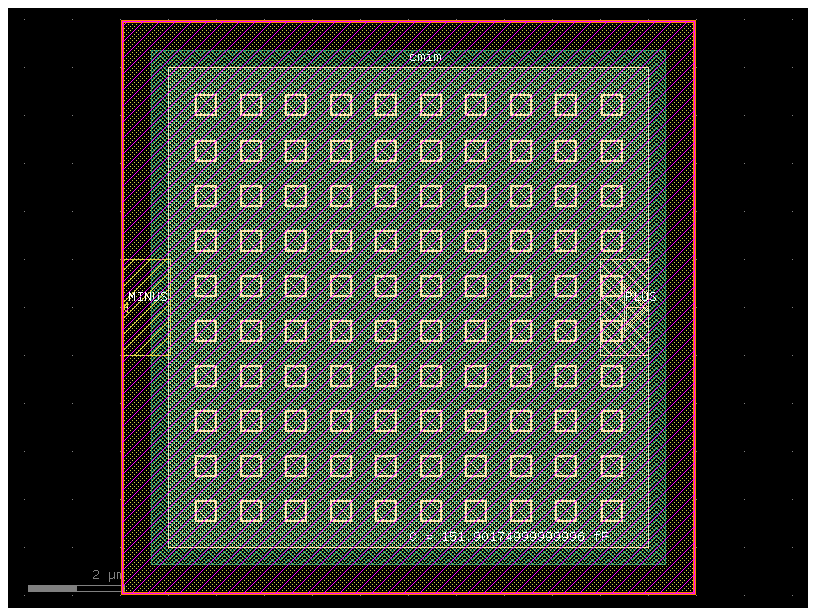

In [ ]:
from ihp import PDK, cells

PDK.activate()

cap_width = 10.0  # um
cap_length = 10.0  # um

# IHP cmim: Metal5 (bottom plate, MINUS) -> MIM dielectric (0.19 um SiO2)
#   -> 10x10 Vmim vias (0.42 um, pitch 0.94 um) -> TopMetal1 (top plate, PLUS)
c = cells.cmim(width=cap_width, length=cap_length).copy()
print("Ports:", [(p.name, tuple(p.center)) for p in c.ports])

cc = c.copy()
cc.draw_ports()
cc

### Configure ElectrostaticSim

In [ ]:
from gsim.palace import ElectrostaticSim

sim = ElectrostaticSim()

sim.set_output_dir("./palace-sim-electrostatic")
sim.set_geometry(c)
sim.set_stack(substrate_thickness=2.0)
sim.set_airbox(margin_x=5, margin_y=5, z_above=5, z_below=5)

# Metal5 = bottom plate (MINUS), TopMetal1 = top plate (PLUS)
sim.add_terminal("T1", layer="metal5")
sim.add_terminal("T2", layer="topmetal1")

sim.set_electrostatic()

print(sim.validate_config())

Validation: PASSED


### Mesh and generate config

In [ ]:
# Vmim vias are 0.42 um with 0.52 um gaps; MIM dielectric is 0.19 um thick
sim.mesh(preset="fine", refined_mesh_size=0.1, merge_via_distance=0)

Mesh Summary
Dimensions: 31.9 x 31.9 x 27.9 µm
Nodes:      64,567
Elements:   480,531
Tetrahedra: 366,459
Edge length: 0.01 - 9.71 µm
Quality:    0.607 (min: 0.008)
SICN:       0.662 (all valid)
----------------------------------------
Volumes (5):
  - mim [1]
  - vmim [2]
  - si [3]
  - sin [4]
  - air [5]
Surfaces (10):
  - metal5_xy [6]
  - metal5_z [7]
  - topmetal1_xy [8]
  - topmetal1_z [9]
  - mim__si [10]
  - si__vmim [11]
  - air__si [12]
  - si__sin [13]
  - air__sin [14]
  - air__None [15]
----------------------------------------
Mesh:   palace-sim-electrostatic/palace.msh

In [ ]:
# sim.plot_mesh(show_groups=["metal", "topmetal", "via", "dielectric", "SiO2__vmim"])

sim.plot_mesh(show_groups=["metal5", "topmetal1", "vmim", "SiO2__vmim"])

# sim.plot_mesh(
#     style="solid",
#     transparent_groups=["air__None", "sio2__None", "air__sio2", "air__passive"],
#     interactive=True,
# )

Widget(value='<iframe src="http://localhost:49777/index.html?ui=P_0x1663c6e10_6&reconnect=auto" class="pyvista…

### IHP PDK compact-model reference

This is the value the IHP `cap_cmim` SPICE device would report for the same
geometry. We evaluate the PDK's own area+perimeter law using the process constants
from the active techParams (`caspec` [F/m^2], `cpspec` [F/m], `lwd` [m]), so the
reference is authoritative rather than hand-tuned. This is the number to compare the
Palace mutual capacitance `Cm[1,2]` against.

In [ ]:
from ihp.cells2.ihp_pycell.utility_functions import Numeric
from ihp.tech import techParams

caspec = Numeric(techParams["cmim_caspec"])  # F/m^2  area-specific capacitance
cpspec = Numeric(techParams["cmim_cpspec"])  # F/m    perimeter-specific capacitance
lwd = Numeric(techParams["cmim_lwd"])  # m      line-width delta

# Use the device w/l (what the SPICE model is parameterized by), in meters.
leff = cap_width * 1e-6 + lwd
weff = cap_length * 1e-6 + lwd

C_pdk_area = caspec * leff * weff
C_pdk_perim = cpspec * 2.0 * (leff + weff)
C_pdk = C_pdk_area + C_pdk_perim

print(f"IHP model '{techParams['cmim_model']}' for {cap_width} x {cap_length} um cmim:")
print(f"  area term      = {C_pdk_area * 1e15:7.2f} fF")
print(f"  perimeter term = {C_pdk_perim * 1e15:7.2f} fF")
print(f"  C_pdk (total)  = {C_pdk * 1e15:7.2f} fF   <- reference for Palace Cm[1,2]")

IHP model 'cap_cmim' for 10.0 x 10.0 um cmim:
  area term      =  150.30 fF
  perimeter term =    1.60 fF
  C_pdk (total)  =  151.90 fF   <- reference for Palace Cm[1,2]


### Run on cloud

Uncomment to submit to GDSFactory+ cloud. The result should be a capacitance matrix CSV.

In [ ]:
results = sim.run()

  palace-938301e5  completed  1m 14s
Extracting results.tar.gz...
Downloaded 11 files to /Users/vahid/doplaydo/gsim/nbs/sim-data-palace-938301e5


### Load and analyze results

In [ ]:
import csv
from pathlib import Path

import numpy as np

results_dir = Path(results["terminal-C.csv"]).parent


def read_palace_csv(path):
    """Read a Palace output CSV, returning header and data as numpy array."""
    with open(path) as f:
        reader = csv.reader(f)
        header = next(reader)
        data = np.array([[float(x) for x in row] for row in reader])
    return [h.strip() for h in header], data


# Maxwell capacitance matrix (terminal-C.csv): diagonal = self-capacitance,
# off-diagonal = negative induced charge on the grounded neighbor.
header, C_matrix = read_palace_csv(results_dir / "terminal-C.csv")
print("Maxwell capacitance matrix (F):")
print(f"  C[1,1] = {C_matrix[0, 1]:+.4e} F  ({C_matrix[0, 1] * 1e15:+.3f} fF)")
print(f"  C[1,2] = {C_matrix[0, 2]:+.4e} F  ({C_matrix[0, 2] * 1e15:+.3f} fF)")
print(f"  C[2,1] = {C_matrix[1, 1]:+.4e} F  ({C_matrix[1, 1] * 1e15:+.3f} fF)")
print(f"  C[2,2] = {C_matrix[1, 2]:+.4e} F  ({C_matrix[1, 2] * 1e15:+.3f} fF)")

# Mutual (lumped "SPICE") matrix (terminal-Cm.csv): off-diagonal is the physical
# plate-to-plate capacitor. Cm[1,2] is the device capacitance the PDK models.
_, Cm = read_palace_csv(results_dir / "terminal-Cm.csv")
print(f"\nMutual (plate-to-plate) capacitance  Cm[1,2] = {Cm[0, 2] * 1e15:.3f} fF")

# Domain energy
_, E = read_palace_csv(results_dir / "domain-E.csv")
print(
    f"\nStored electric energy: {E[0, 1]:.4e} J (excitation 1), {E[1, 1]:.4e} J (excitation 2)"
)

Maxwell capacitance matrix (F):
  C[1,1] = +2.1692e-14 F  (+21.692 fF)
  C[1,2] = -2.1692e-14 F  (-21.692 fF)
  C[2,1] = -2.1692e-14 F  (-21.692 fF)
  C[2,2] = +2.1692e-14 F  (+21.692 fF)

Mutual (plate-to-plate) capacitance  Cm[1,2] = 21.692 fF

Stored electric energy: 4.0861e-12 J (excitation 1), 4.0861e-12 J (excitation 2)


### Compare: Palace vs IHP PDK model

The Palace plate-to-plate capacitance is `Cm[1,2]` (equivalently `|C[1,2]|`),
compared against the IHP `cap_cmim` compact-model value `C_pdk`.

In [ ]:
# Palace device (mutual) capacitance — the quantity the PDK models.
C_palace = abs(Cm[0, 2])

print(f"Palace mutual Cm[1,2]:      {C_palace * 1e15:.3f} fF")
print(f"IHP PDK model (cap_cmim):   {C_pdk * 1e15:.3f} fF")

Palace mutual Cm[1,2]:      21.692 fF
IHP PDK model (cap_cmim):   151.902 fF
